In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

path = "../data/netflix_titles.csv"
df = pd.read_csv(path)
print(f"Dataset: {df.shape[0]:,} title, {df.shape[1]} sütun")

print("\nBoş dəyər faizləri:")
missing_pct = (df.isna().mean() * 100).round(1)
print(missing_pct[missing_pct > 0])
df[['director', 'cast', 'country']] = df[['director', 'cast', 'country']].fillna('Unknown')

print(f"\nType paylanması:")
print(df['type'].value_counts())
print((df['type'].value_counts(normalize=True) * 100).round(1))

Dataset: 8,807 title, 12 sütun

Boş dəyər faizləri:
director      29.9
cast           9.4
country        9.4
date_added     0.1
dtype: float64

Type paylanması:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64
type
Movie      69.6
TV Show    30.4
Name: proportion, dtype: float64


In [2]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
print(f"date_added parse edilə bilməyən sətir sayı: {df['date_added'].isna().sum()}")
print(f"\nyear_added aralığı: {df['year_added'].min():.0f} -> {df['year_added'].max():.0f}")

date_added parse edilə bilməyən sətir sayı: 10

year_added aralığı: 2008 -> 2021


In [3]:
yearly_growth = df['year_added'].value_counts().sort_index()
yearly_growth

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

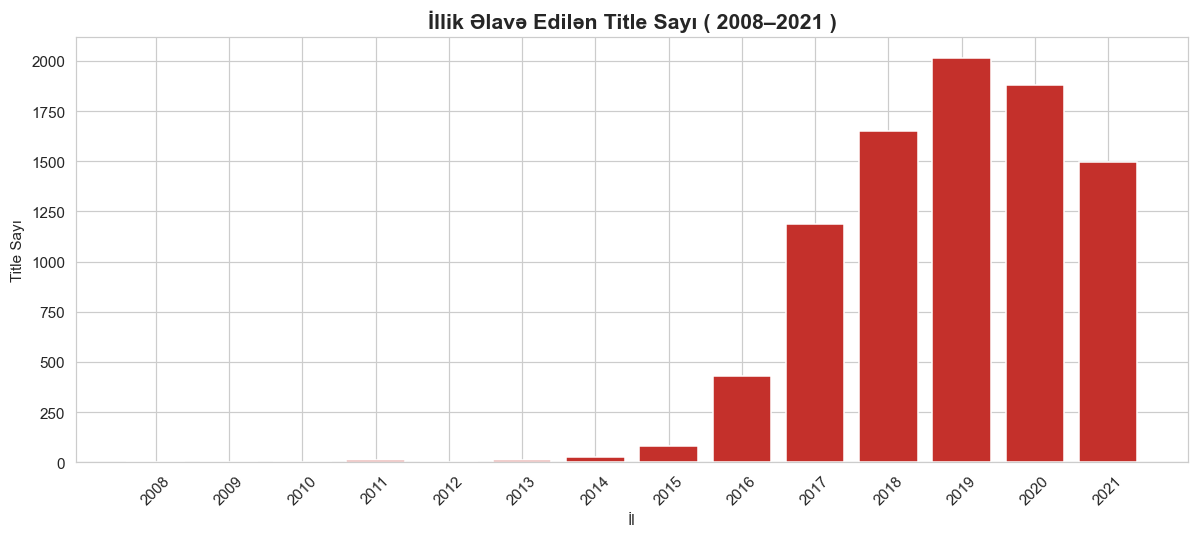

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(yearly_growth.index.astype(int).astype(str), yearly_growth.values, color='#C4302B', edgecolor='white')
ax.set_title('İllik Əlavə Edilən Title Sayı ( 2008–2021 )', fontsize=14, fontweight='bold')
ax.set_xlabel('İl')
ax.set_ylabel('Title Sayı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('yearly_growth.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
type_pivot = pd.crosstab(df['year_added'], df['type'])
type_pivot_pct = type_pivot.div(type_pivot.sum(axis=1), axis=0) * 100
type_pivot_pct.round(1)

type,Movie,TV Show
year_added,,
2008.0,50.0,50.0
2009.0,100.0,0.0
2010.0,100.0,0.0
2011.0,100.0,0.0
2012.0,100.0,0.0
2013.0,54.5,45.5
2014.0,79.2,20.8
2015.0,68.3,31.7
2016.0,59.0,41.0


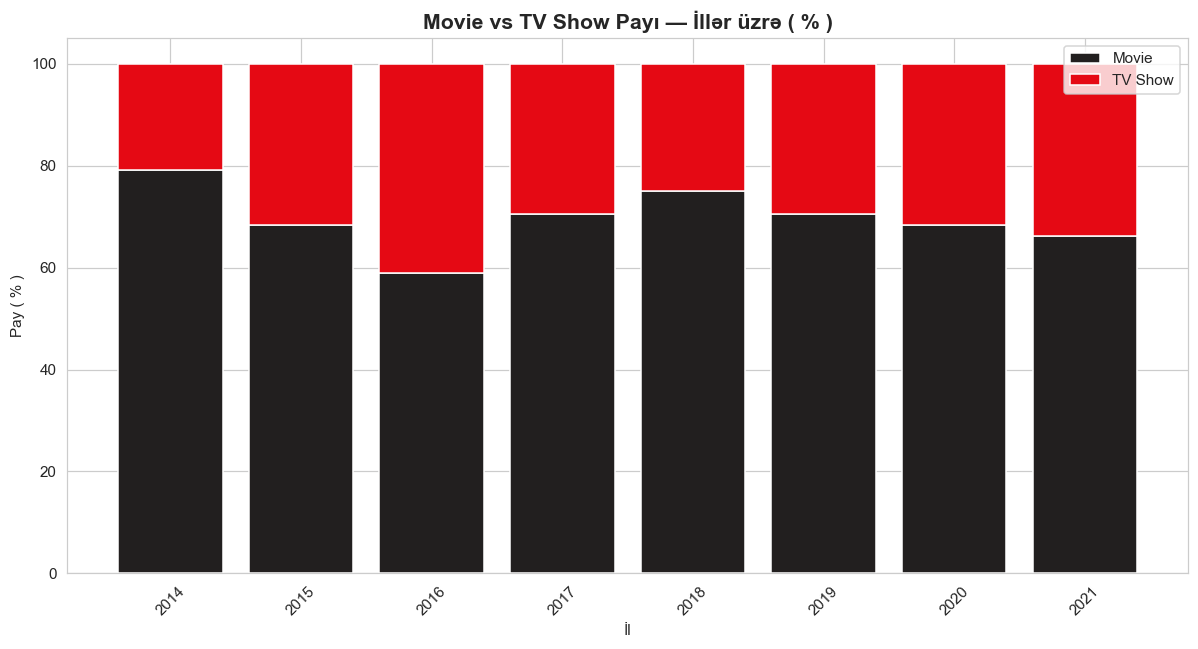

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
years_to_plot = type_pivot_pct.index[type_pivot_pct.index >= 2014]
plot_data = type_pivot_pct.loc[years_to_plot]
ax.bar(plot_data.index.astype(int).astype(str), plot_data['Movie'], label='Movie', color='#221F1F')
ax.bar(plot_data.index.astype(int).astype(str), plot_data['TV Show'], bottom=plot_data['Movie'],
       label='TV Show', color='#E50914')

ax.set_title('Movie vs TV Show Payı — İllər üzrə ( % )', fontsize=14, fontweight='bold')
ax.set_xlabel('İl')
ax.set_ylabel('Pay ( % )')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('strategy_shift_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df['genre_list'] = df['listed_in'].str.split(', ')
genre_exploded = df.explode('genre_list')
top15_genres = genre_exploded['genre_list'].value_counts().head(15)
top15_genres

genre_list
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

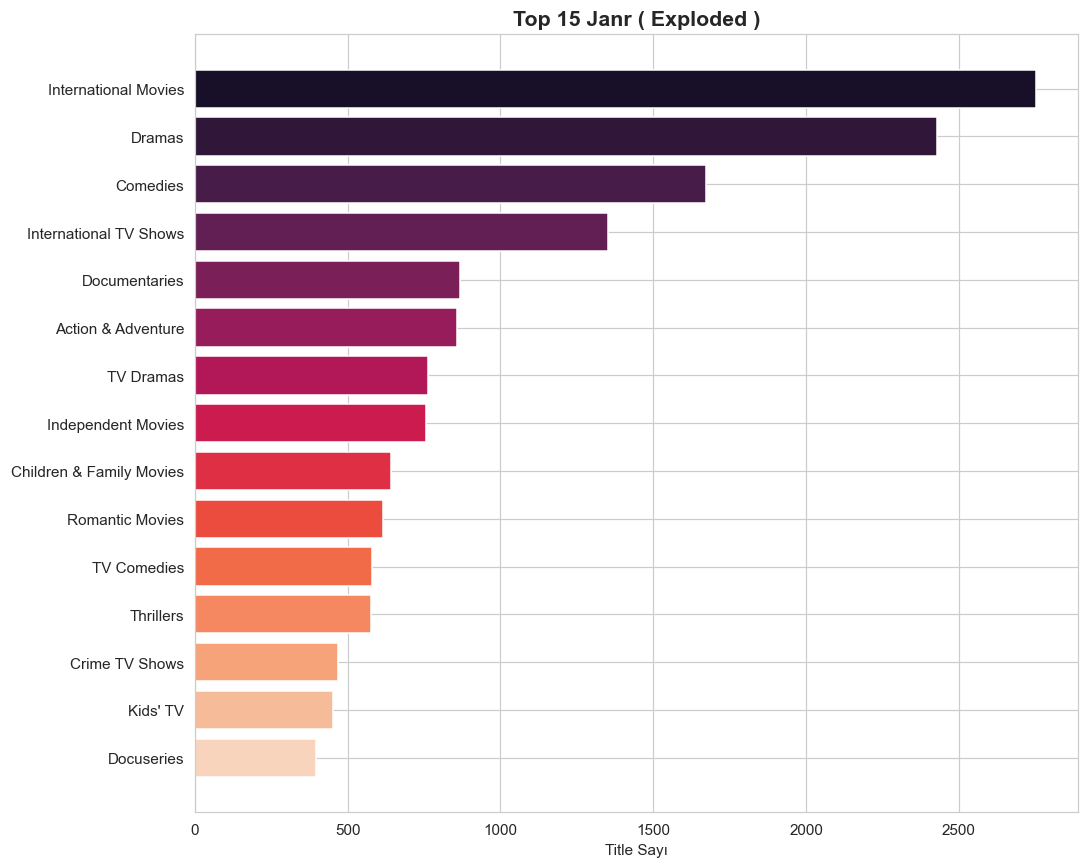

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette('rocket', len(top15_genres))
ax.barh(top15_genres.index[::-1], top15_genres.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Janr ( Exploded )', fontsize=14, fontweight='bold')
ax.set_xlabel('Title Sayı')
plt.tight_layout()
plt.savefig('top15_genres.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
top10_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
top10_countries

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [10]:
country_type_split = df[df['country'].isin(top10_countries.index)].groupby(
    ['country', 'type']
).size().unstack(fill_value=0)
country_type_split = country_type_split.reindex(top10_countries.index)
country_type_split

type,Movie,TV Show
country,,
United States,2058,760
India,893,79
United Kingdom,206,213
Japan,76,169
South Korea,41,158
Canada,122,59
Spain,97,48
France,75,49
Mexico,70,40


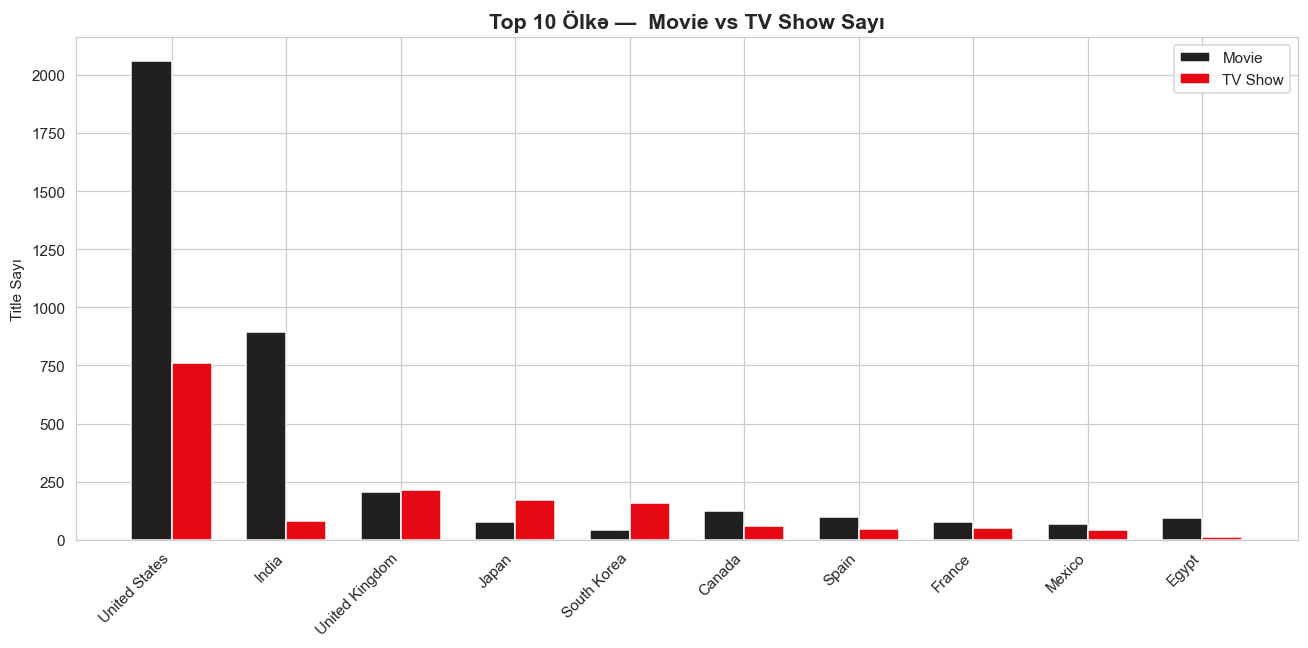

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(country_type_split))
width = 0.35
ax.bar(x - width/2, country_type_split['Movie'], width, label='Movie', color='#221F1F')
ax.bar(x + width/2, country_type_split['TV Show'], width, label='TV Show', color='#E50914')
ax.set_xticks(x)
ax.set_xticklabels(country_type_split.index, rotation=45, ha='right')
ax.set_title('Top 10 Ölkə —  Movie vs TV Show Sayı', fontsize=14, fontweight='bold')
ax.set_ylabel('Title Sayı')
ax.legend()
plt.tight_layout()
plt.savefig('top10_countries_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
tv_shows = df[df['type'] == 'TV Show'].copy()
tv_shows['seasons'] = tv_shows['duration'].str.extract(r'(\d+)').astype(float)
def season_bucket(s):
    if s == 1:
        return '1 mövsüm'
    elif s == 2:
        return '2 mövsüm'
    elif s == 3:
        return '3 mövsüm'
    else:
        return '4+ mövsüm'

tv_shows['season_bucket'] = tv_shows['seasons'].apply(season_bucket)
season_order = ['1 mövsüm', '2 mövsüm', '3 mövsüm', '4+ mövsüm']
season_dist = tv_shows['season_bucket'].value_counts().reindex(season_order)
season_dist

season_bucket
1 mövsüm     1793
2 mövsüm      425
3 mövsüm      199
4+ mövsüm     259
Name: count, dtype: int64

In [13]:
one_season_pct = (tv_shows['seasons'] == 1).mean() * 100
print(f"1-mövsümlü TV Show payı: {one_season_pct:.1f}%")

1-mövsümlü TV Show payı: 67.0%


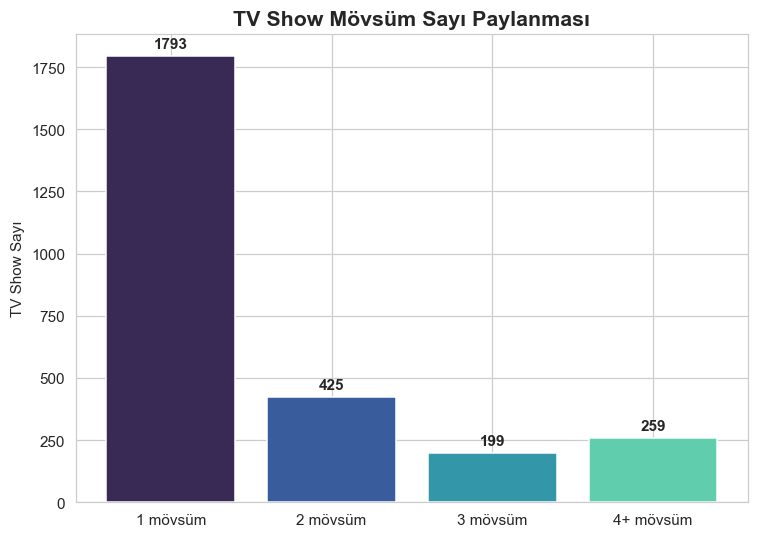

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette('mako', len(season_dist))
bars = ax.bar(season_dist.index, season_dist.values, color=colors, edgecolor='white')
for bar, val in zip(bars, season_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20, str(val), ha='center', va='bottom', fontweight='bold')

ax.set_title('TV Show Mövsüm Sayı Paylanması', fontsize=14, fontweight='bold')
ax.set_ylabel('TV Show Sayı')
plt.tight_layout()
plt.savefig('season_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
overall_rating = df['rating'].value_counts().head(10)
print("Ümumi content rating (top 10):")
print(overall_rating)
print()
print("Movie üçün top 5 rating:")
print(df[df['type'] == 'Movie']['rating'].value_counts().head(5))
print()
print("TV Show üçün top 5 rating:")
print(df[df['type'] == 'TV Show']['rating'].value_counts().head(5))

Ümumi content rating (top 10):
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

Movie üçün top 5 rating:
rating
TV-MA    2062
TV-14    1427
R         797
TV-PG     540
PG-13     490
Name: count, dtype: int64

TV Show üçün top 5 rating:
rating
TV-MA    1145
TV-14     733
TV-PG     323
TV-Y7     195
TV-Y      176
Name: count, dtype: int64


In [16]:
month_dist = df['month_added'].value_counts().sort_index()
month_names = ['Yan', 'Fev', 'Mar', 'Apr', 'May', 'İyn', 'İyl', 'Avq', 'Sen', 'Okt', 'Noy', 'Dek']
month_dist.index = month_names
month_dist

Yan    738
Fev    563
Mar    742
Apr    764
May    632
İyn    728
İyl    827
Avq    755
Sen    770
Okt    760
Noy    705
Dek    813
Name: count, dtype: int64

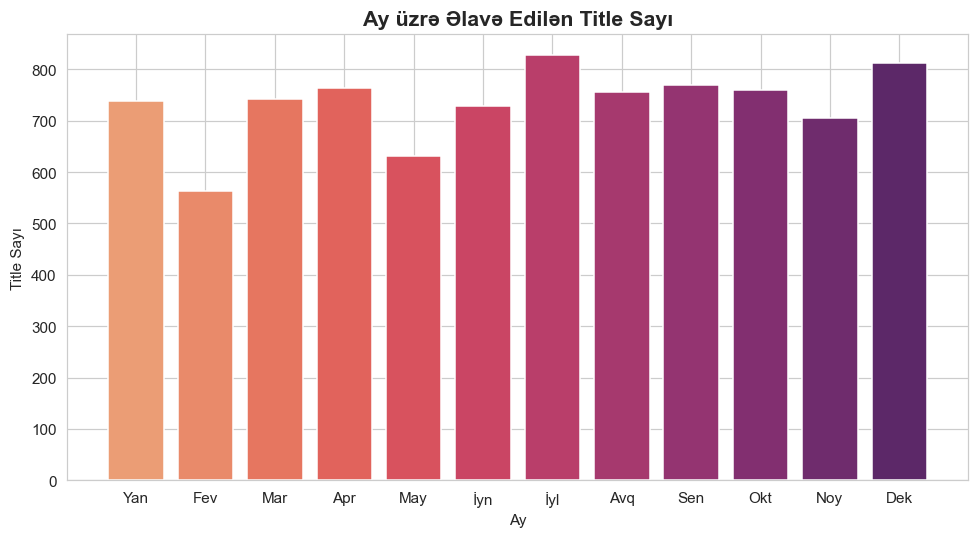

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('flare', 12)
bars = ax.bar(month_dist.index, month_dist.values, color=colors, edgecolor='white')
ax.set_title('Ay üzrə Əlavə Edilən Title Sayı', fontsize=14, fontweight='bold')
ax.set_xlabel('Ay')
ax.set_ylabel('Title Sayı')
plt.tight_layout()
plt.savefig('monthly_additions.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
df['release_gap'] = df['year_added'] - df['release_year']
gap_by_country = df[df['country'].isin(top10_countries.index)].groupby('country')['release_gap'].mean()
gap_by_country = gap_by_country.reindex(top10_countries.index).sort_values(ascending=False)
gap_by_country.round(2)

country
Egypt             10.49
India              6.76
United States      5.47
Japan              4.72
United Kingdom     3.16
Mexico             2.35
Canada             2.09
France             1.97
South Korea        1.70
Spain              0.72
Name: release_gap, dtype: float64

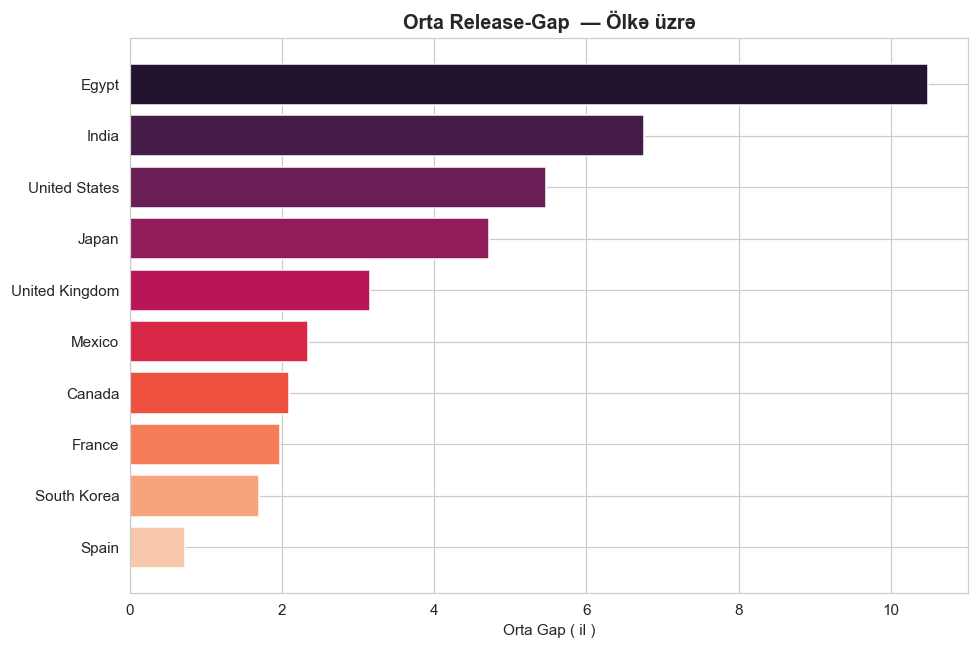

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('rocket', len(gap_by_country))
ax.barh(gap_by_country.index[::-1], gap_by_country.values[::-1], color=colors[::-1])
ax.set_title('Orta Release-Gap  — Ölkə üzrə', fontsize=13, fontweight='bold')
ax.set_xlabel('Orta Gap ( il )')
plt.tight_layout()
plt.savefig('release_gap_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
directors_known = df[df['director'] != 'Unknown']
top5_directors = directors_known['director'].value_counts().head(5)
print("Top 5 rejissor:")
print(top5_directors)
print()
for director in top5_directors.index:
    sub = directors_known[directors_known['director'] == director]
    genres = sub['listed_in'].str.split(', ').explode().value_counts().head(3)
    print(f"{director} ({top5_directors[director]} title): {dict(genres)}")

Top 5 rejissor:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Name: count, dtype: int64

Rajiv Chilaka (19 title): {'Children & Family Movies': np.int64(19), 'Sports Movies': np.int64(1)}
Raúl Campos, Jan Suter (18 title): {'Stand-Up Comedy': np.int64(18)}
Suhas Kadav (16 title): {'Children & Family Movies': np.int64(16), 'Comedies': np.int64(8), 'Music & Musicals': np.int64(5)}
Marcus Raboy (16 title): {'Stand-Up Comedy': np.int64(15), 'Stand-Up Comedy & Talk Shows': np.int64(1), 'TV Comedies': np.int64(1)}
Jay Karas (14 title): {'Stand-Up Comedy': np.int64(13), 'Children & Family Movies': np.int64(1), 'Comedies': np.int64(1)}
